In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kradarsh04/embeddings/train_embeddings.npy
/kaggle/input/datasets/kradarsh04/embeddings/val_embeddings.npy
/kaggle/input/datasets/kradarsh04/embeddings/test_embeddings.npy
/kaggle/input/datasets/kradarsh04/recent-model/xgb_modelv1_nonltk.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_hpt_v1.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_model_m3.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_model.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_final_v2.pkl
/kaggle/input/datasets/kradarsh04/recent-model/final_lgbm_03.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_model_m3_nonltk.pkl
/kaggle/input/datasets/kradarsh04/recent-model/lgbm_v18_final.pkl
/kaggle/input/datasets/kradarsh04/recent-model/xgb_modelv1.pkl
/kaggle/input/datasets/kradarsh04/tfidf-files/X_train_tfidf.npz
/kaggle/input/datasets/kradarsh04/tfidf-files/X_val_tfidf.npz
/kaggle/input/datasets/kradarsh04/tfidf-files/X_test_tfidf.npz
/kaggle/input/competition

In [2]:
# imp libs
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from pathlib import Path
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from scipy.sparse import hstack, csr_matrix

# Data loading and integration

In [3]:
df_test  = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")

df_train = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
sample = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv")

In [4]:
df_test["is_train"] = 0
df_train["is_train"] = 1

In [5]:
df = pd.concat([df_train, df_test], ignore_index=True) #merged it so we can perform essential eda and fe on both datasets together

# **Main Code start:**

## Starting with feature engi and EDA on both train and test data together


In [6]:
numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
len(numerical_objs)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   created_date  300000 non-null  object 
 1   post_id       300000 non-null  int64  
 2   emoticon_1    300000 non-null  int64  
 3   emoticon_2    300000 non-null  int64  
 4   emoticon_3    300000 non-null  int64  
 5   upvote        300000 non-null  int64  
 6   downvote      300000 non-null  int64  
 7   if_1          300000 non-null  int64  
 8   if_2          300000 non-null  int64  
 9   race          79308 non-null   object 
 10  religion      79308 non-null   object 
 11  gender        79308 non-null   object 
 12  disability    300000 non-null  bool   
 13  comment       299999 non-null  object 
 14  label         198000 non-null  float64
 15  is_train      300000 non-null  int64  
dtypes: bool(1), float64(1), int64(9), object(5)
memory usage: 34.6+ MB


In [7]:
#categorical cols
display(df['race'].unique())
display(df['religion'].unique())
display(df['gender'].unique())
display(df['disability'].unique())
display(df['created_date'].unique())

# df[~df['race'].isna()]

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

array([False,  True])

array(['2024-01-18 08:43:57.397508+00:00',
       '2024-03-24 21:43:11.490017+00:00',
       '2024-04-24 20:32:17.014931+00:00', ...,
       '2023-10-26 15:41:55.972421+00:00',
       '2024-02-28 11:25:10.033561+00:00',
       '2022-12-30 06:10:30.575151+00:00'], dtype=object)

In [8]:
#@title handling datetime: 
df['created_date'] = pd.to_datetime(df['created_date'], yearfirst=True)
# creating separate day, month, year
df['Day'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.day.astype(int)
df['Month'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.month.astype(int)
df['Year'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.year.astype(int)
df
df['weekday'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.weekday.astype(int)
df['weekend'] = df['weekday'].isin([5,6]).astype(int) #to fetch the weekends
df['created_hour'] = pd.to_datetime(df['created_date']).dt.hour

In [9]:
df.post_id.unique()
df.info()
# pd.get_dummies(df['race']) #not effective will use ohe later..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  300000 non-null  datetime64[ns, UTC]
 1   post_id       300000 non-null  int64              
 2   emoticon_1    300000 non-null  int64              
 3   emoticon_2    300000 non-null  int64              
 4   emoticon_3    300000 non-null  int64              
 5   upvote        300000 non-null  int64              
 6   downvote      300000 non-null  int64              
 7   if_1          300000 non-null  int64              
 8   if_2          300000 non-null  int64              
 9   race          79308 non-null   object             
 10  religion      79308 non-null   object             
 11  gender        79308 non-null   object             
 12  disability    300000 non-null  bool               
 13  comment       299999 non-null  object       

### Handling categorical features: 

In [10]:
#race, religion, gender : categorical to numerical
df.isna().sum()
# race, religion, gender : categorical to numerical
cols = ['race', 'religion', 'gender']
for i in cols:
    df[i+'_missing'] = df[i].isna().astype(int)
    df[i]= df[i].fillna("Missing").astype(str)

In [11]:
#insigts from graphs, trans people are usually label 1
df['is_trans'] = (df['gender'] == 'transgender').astype(int) #hight signa, for 1


### Handling comments:

In [12]:
# cleaning and removing noise: 
df['comment'] = df['comment'].str.replace(r'http\S+', '', regex=True)
df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
df[:3]['comment']

# handing missing vals:
df['comment'] = df['comment'].fillna('').astype(str)
df['comment_len'] = df['comment'].str.len()
df['word_cnt'] = df['comment'].str.split().str.len()
# pd.set_option('display.max_colwidth', None)
df["avg_words"] =df["comment_len"] /(df["word_cnt"]+1)
# df['comment']= df['comment'].str.join(" ")

In [13]:
#some text intensive features:
df['num_!'] = df['comment'].str.count('!')
df['num_ques'] = df['comment'].str.count(r'\?')
pd.set_option('display.max_colwidth', None)
df['comment'].head(3)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
1                                                                                                                Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights 

### Handling Emojis and Imp columns

In [14]:
df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']

#### Handling Votes and performing FE on them: Engagement signls

**Let's see what all can we do with it:**
1. Total votes (we can simply sum them)
2. ratio of upvotes to downvotes(get the ratio)

*These are strong internal signal that'd be useful for prediction*

In [15]:
# df[['upvote', 'downvote']]
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]

#balancing the magnitude, popularity magnitude o9r negative feedback magnitude using log1p
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])

#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emoji_counts'] / (df['word_cnt'] + 1)
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density'],
      dtype='object')

In [16]:
# df.groupby('post_id').size().
post_counts = df[df['is_train']==1].groupby('post_id').size().rename('post_comments_count')

df['post_comments_count'] = df['post_id'].map(post_counts).fillna(0).astype(int)

In [17]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density', 'post_comments_count'],
      dtype='object')

In [18]:
# df.dtypes
dubli_cnt = df.duplicated(subset=['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'race_missing', 'religion_missing', 'gender_missing',
       'comment_len', 'word_cnt', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1','engagement_score', 'emoticon_density', 'post_comments_count']).sum() # the comment col is list, to avoid typeerror 
# missing flags 
print("no of dublicates in dataset: ",dubli_cnt)
display(df.describe().T)
# display(df.info())

no of dublicates in dataset:  0


,count,mean,std,min,25%,50%,75%,max
post_id,300000.0,68.417507,27.939911,20.0,39.000,72.000000,72.000000,129.000000
emoticon_1,300000.0,0.279873,1.030117,0.0,0.000,0.000000,0.000000,95.000000
emoticon_2,300000.0,0.048343,0.258069,0.0,0.000,0.000000,0.000000,11.000000
emoticon_3,300000.0,0.120333,0.480833,0.0,0.000,0.000000,0.000000,19.000000
upvote,300000.0,2.608460,5.024763,0.0,0.000,1.000000,3.000000,201.000000
downvote,300000.0,0.664787,2.017886,0.0,0.000,0.000000,1.000000,107.000000
if_1,300000.0,1.905107,25.854302,0.0,0.000,0.000000,4.000000,1866.000000
if_2,300000.0,7.956210,14.958419,3.0,4.000,6.000000,10.000000,1833.000000
label,198000.0,0.793965,0.979808,0.0,0.000,0.000000,2.000000,3.000000
is_train,300000.0,0.660000,0.473710,0.0,0.000,1.000000,1.000000,1.000000


In [19]:
# outliers 
def iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr 
    return lower, upper, (s<lower).sum(), (s>upper).sum()

print("the Extreme valeus are :")
for i in ['upvote', 'downvote', 'if_1', 'if_2']:
    l,u,below,above = iqr(df[i])
    print(f"{i}: lower={l:.2f}, upper={u:.2f}, below={below}, above={above}")

# df['upvote'].quantile(0.75)

the Extreme valeus are :
upvote: lower=-4.50, upper=7.50, below=0, above=26337
downvote: lower=-1.50, upper=2.50, below=0, above=22989
if_1: lower=-6.00, upper=10.00, below=0, above=127
if_2: lower=-5.00, upper=19.00, below=0, above=5938


In [20]:
# i had somehow ignored the if_1 and 2 so let's resolve it - it'll give some boost to f1_score (it actaully gave 0.02 boost)
df["if_1_log"] = np.log1p(df["if_1"])
df["if_2_log"] = np.log1p(df["if_2"])

df["if_interaction_log"] = df["if_1_log"] * df["if_2_log"]

In [21]:
# #sentiment score
# import nltk
# from nltk.sentiment.vader import SentimentIntensityAnalyzer
# from tqdm.auto import tqdm

# nltk.download('vader_lexicon')
# sia = SentimentIntensityAnalyzer()
# comments_list = df['comment'].astype(str).tolist()

# print("Running Senti. Analysis..")
# sentiment_scores = [sia.polarity_scores(text)['compound'] for text in tqdm(comments_list)]
# df['sentiment_vader'] = sentiment_scores
# print("Done..")

In [22]:
#got insigts from heatmap
# df['if_interaction_sentiment'] = df['if_interaction_log'] * df['sentiment_vader']

In [23]:
# print(df['if_interaction_sentiment'].describe())
# print(f"% of Zero's: {(df['if_interaction_sentiment']==0).mean()*100:.1f}%")
# #since it's below 90% it's useful..

In [24]:
### Splitting before Encoding and all
df['disability'] = df['disability'].astype(int) #0's false

display(df['race'].unique(),
df['religion'].unique(),
df['gender'].unique(),
df['post_id'].unique())

array(['Missing', 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

array(['Missing', 'christian', 'muslim', 'none', 'jewish', 'atheist',
       'other', 'hindu', 'buddhist'], dtype=object)

array(['Missing', 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

### Final cleaning and separating train and test data

In [25]:
final_df = df.copy(deep=True)

# removing redundent cols:
final_df.drop(['created_date', 'Day', 'Month', 'Year'], axis=1, inplace=True)
final_df.drop(['upvote','downvote'], axis=1, inplace=True) #a few more
final_df.dtypes

#separating the train and test dataset
train_df = final_df[final_df['is_train'] == 1].copy(deep= True)
test_df = final_df[final_df['is_train'] == 0].copy(deep= True)
print(df_train.shape
, final_df.shape, df_test.shape) #just to verfiy the separation wnet smoothly

print(train_df.shape
, final_df.shape, test_df.shape)

(198000, 16) (300000, 35) (102000, 15)
(198000, 35) (300000, 35) (102000, 35)


### Splitting the train dataset: Real ML 

In [26]:
train_df.columns
x_ = train_df.drop(columns=['label'])
y_ = train_df['label'].astype(int).values
x_.shape, y_.shape
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_,
    y_,
    test_size=0.2,
    stratify=y_,
    random_state=42
)

In [27]:
# test_df.columns
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((158400, 34), (158400,), (39600, 34), (39600,))

In [28]:
# post_stats = X_train.assign(label= y_train).groupby("post_id")['label'].agg(post_mean = 'mean', post_std = "std")
# # mapping the label mean found from train to val and test
# post_stats.reset_index().set_index("post_id")

# for data in [X_train, X_val, test_df]:
#     data["post_mean"] = data["post_id"].map(post_stats["post_mean"]).fillna(y_train.mean())
#     data["post_std"] = data["post_id"].map(post_stats["post_std"]).fillna(0.0)
# # X_train[["post_id", 'post_mean',"post_std"]].groupby("post_id").value_counts()

# Encoding categorical features:


In [29]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True) #to avoid crash on unseen dataset
categories = ['race', 'religion', 'gender']

X_train_ohe = ohe.fit_transform(X_train[categories])
X_val_ohe = ohe.transform(X_val[categories])
X_test_ohe = ohe.transform(test_df[categories])
train_df.shape

(198000, 35)

## Performing Tf-idf and Embeddings

*pipeline: word_tfidf + char_tfidf + sentence embeddings*

In [30]:
#@title Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

# word_tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),
#     min_df=3,
#     lowercase=True
# )

# X_train_word = word_tfidf.fit_transform(X_train['comment'])
# X_val_word   = word_tfidf.transform(X_val['comment'])
# X_test_word  = word_tfidf.transform(test_df['comment'])

In [31]:
# char_tfidf = TfidfVectorizer(
#     max_features=5000,
#     analyzer='char',
#     ngram_range=(3,5)
# )

# X_train_char = char_tfidf.fit_transform(X_train['comment'])
# X_val_char   = char_tfidf.transform(X_val['comment'])
# X_test_char  = char_tfidf.transform(test_df['comment'])

In [32]:
# # @title: trying senstece transformer instead of tf-idf to improve context

# from sentence_transformers import SentenceTransformer
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import loguniform

# import torch
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# train_text_emb = model.encode(
#     X_train["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# val_text_emb = model.encode(
#     X_val["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# test_text_emb = model.encode(
#     test_df["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

## Final dataset preprocessing before merger
numericals + scalling

In [33]:
X_train.columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2',
       'race', 'religion', 'gender', 'disability', 'comment', 'is_train',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density', 'post_comments_count', 'if_1_log', 'if_2_log',
       'if_interaction_log'],
      dtype='object')

In [34]:
from scipy.sparse import hstack
#merging the ohe and main dataset
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3','if_1_log',
                'if_2_log','disability', 'weekend', 'created_hour','is_trans',
                'gender_missing', 'comment_len','avg_words',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log']  #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]

#scalling the numericals 
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = StandardScaler()
Rscaler = RobustScaler() #changing this to see any improvs

X_train_num = Rscaler.fit_transform(X_train[numerical_col])
X_val_num   = Rscaler.transform(X_val[numerical_col])
X_test_num  = Rscaler.transform(test_df[numerical_col])

### Final training dataset:
*pipeline: Numericals + Ohe + tf-idf pipeline*

In [35]:
from scipy.sparse import hstack, load_npz
from scipy.sparse import csr_matrix
# X_train_tfidf = hstack([X_train_word, X_train_char])
# X_val_tfidf   = hstack([X_val_word, X_val_char])
# X_test_tfidf  = hstack([X_test_word, X_test_char])

#Directly loaded:
X_train_tfidf = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_train_tfidf.npz')
X_val_tfidf   = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_val_tfidf.npz')
X_test_tfidf  = load_npz('/kaggle/input/datasets/kradarsh04/tfidf-files/X_test_tfidf.npz')

#adding the embeddings 
train_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/train_embeddings.npy')
val_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/val_embeddings.npy')
test_text_emb = np.load('/kaggle/input/datasets/kradarsh04/embeddings/test_embeddings.npy')

X_train_emb_sparse = csr_matrix(train_text_emb)
X_val_emb_sparse   = csr_matrix(val_text_emb)
X_test_emb_sparse  = csr_matrix(test_text_emb)

# join
print("merge start..")
# final dataset
X_train_final = hstack([
    X_train_tfidf,
    X_train_emb_sparse,
    X_train_ohe,
    X_train_num
])

X_val_final = hstack([
    X_val_tfidf,
    X_val_emb_sparse,
    X_val_ohe,
    X_val_num
])

X_test_final = hstack([
    X_test_tfidf,
    X_test_emb_sparse,
    X_test_ohe,
    X_test_num
])
print("merge complete..")

merge start..
merge complete..


### Saving the files to avoid re-complication : To save time

In [36]:
# save_npz('X_train_tfidf.npz', X_train_tfidf)
# print("done")
# save_npz('X_val_tfidf.npz', X_val_tfidf)
# print("done")
# save_npz('X_test_tfidf.npz', X_test_tfidf)
# print("done")

In [37]:
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_final.npz', X_train_final)
# print("done")
# save_npz('X_val_final.npz', X_val_final)
# print("done")
# save_npz('X_test_final.npz', X_test_final)
# print("done")

In [38]:
# np.save('train_embeddings.npy', train_text_emb)
# np.save('val_embeddings.npy', val_text_emb)
# np.save('test_embeddings.npy', test_text_emb)

In [39]:
# from IPython.display import FileLink
# FileLink('X_test_final.npz')

## **Visualisations and Observations:**

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='label', ylabel='count'>

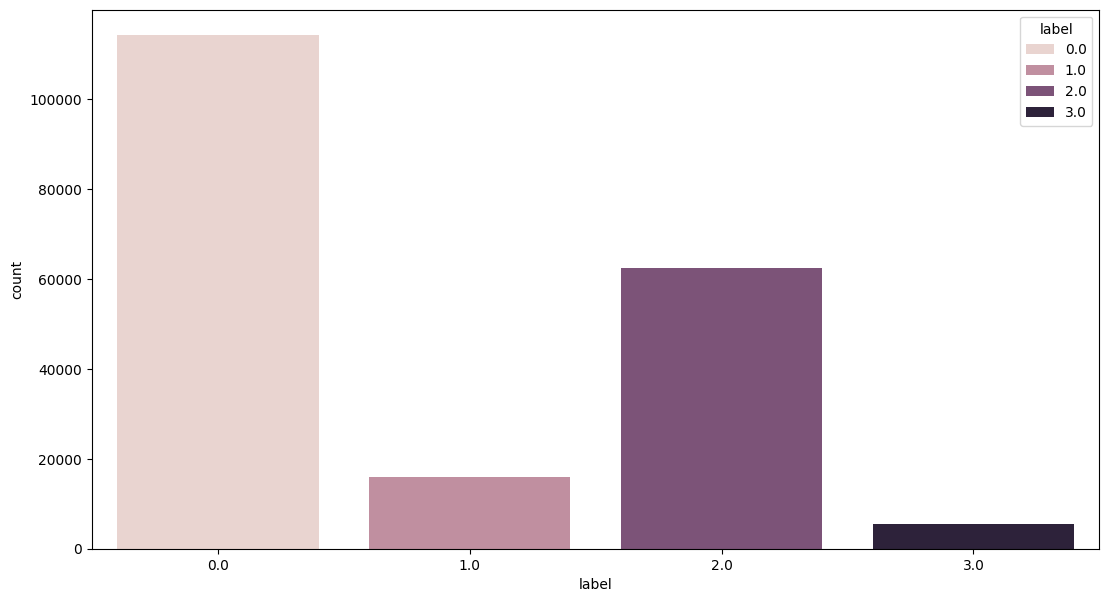

In [41]:
plt.figure(figsize=(13,7))
sns.countplot(x= 'label', data= train_df, hue='label')

### Count vs label
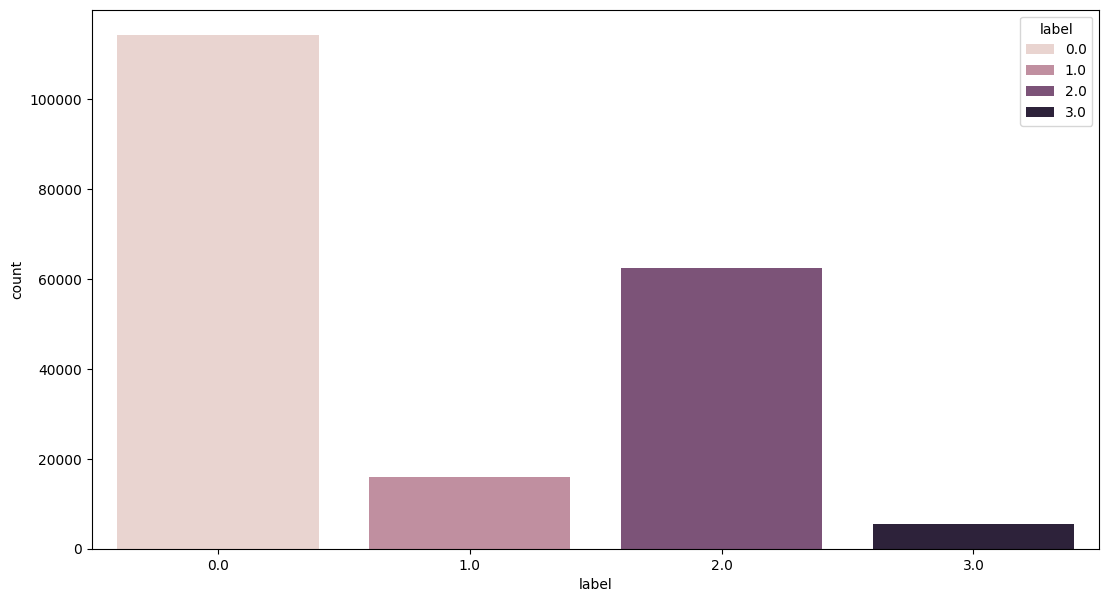
1. massive imbalance
2. 0(>1lkh) >> 2 > 1 >> 3

In [42]:
# sns.violinplot(x= 'label', y = 'comment_len', data = train_df)
# sns.boxenplot(x= 'label', y = 'comment_len', data = train_df)

### Observations: label v/s comment_len 
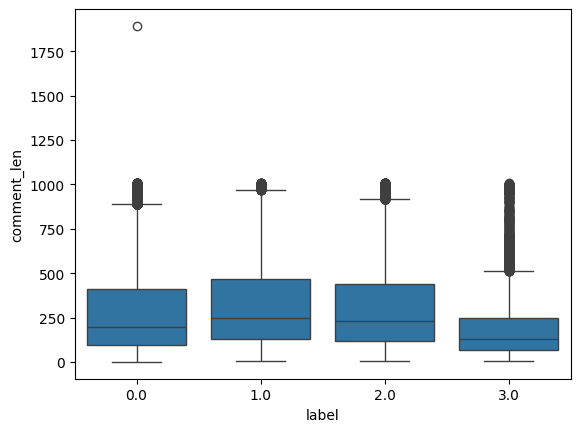
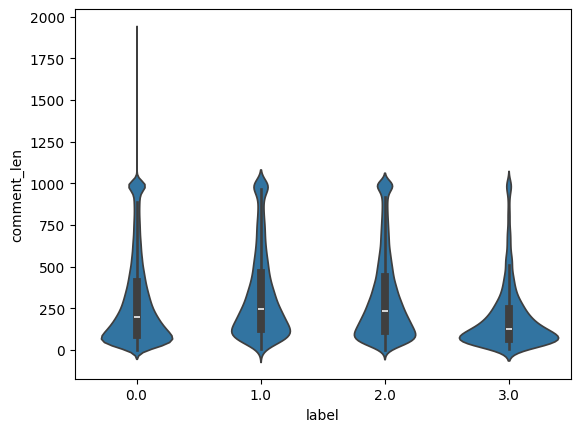
1. we have 1 outlier comment getting 1900~ len even after plateform limit, probably collected due to error in parsing or wasne't cleaned.
2. the higest label has the lowest comment len
3. Since the labels have an invisible sealing of 1000 words it suggests that the platform or API where we got this data from has hard word limit of 1000
4. Lable 3 is odd one out, it's IQR is significantly lower than other 3 
    - whatever comments category label 3 is for people tend to write it short yet there's strangly high volumne of them that push all the way to plateform limit.
1. 1000 word limit


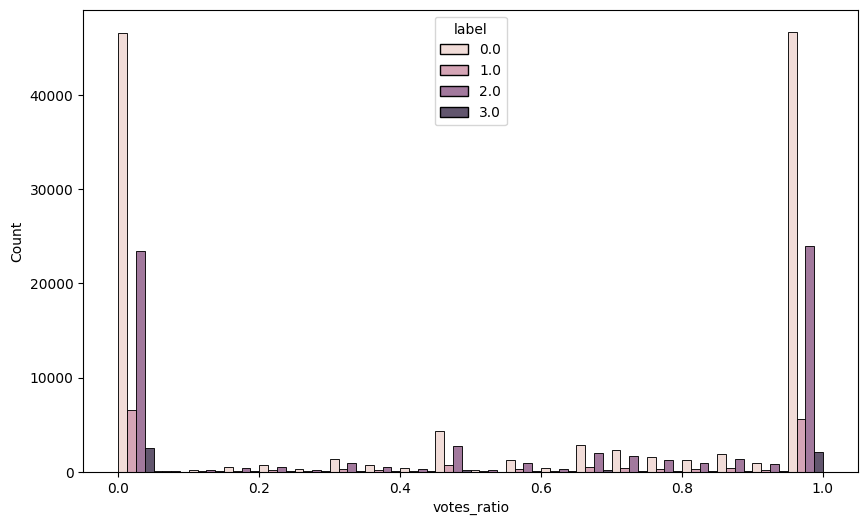

In [43]:
plt.figure(figsize=(10, 6))
# A 1D histogram using hue to separate the labels - great for data clumps across diff labels
sns.histplot(data=train_df, x='votes_ratio', hue='label', bins=20, multiple='dodge')
plt.show()

<Axes: xlabel='label', ylabel='votes_ratio'>

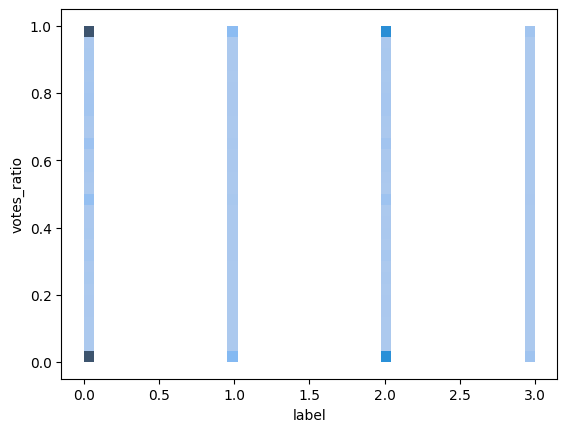

In [44]:
sns.histplot(x= 'label', y = 'votes_ratio', data = train_df)

### Vote Ratio vs label
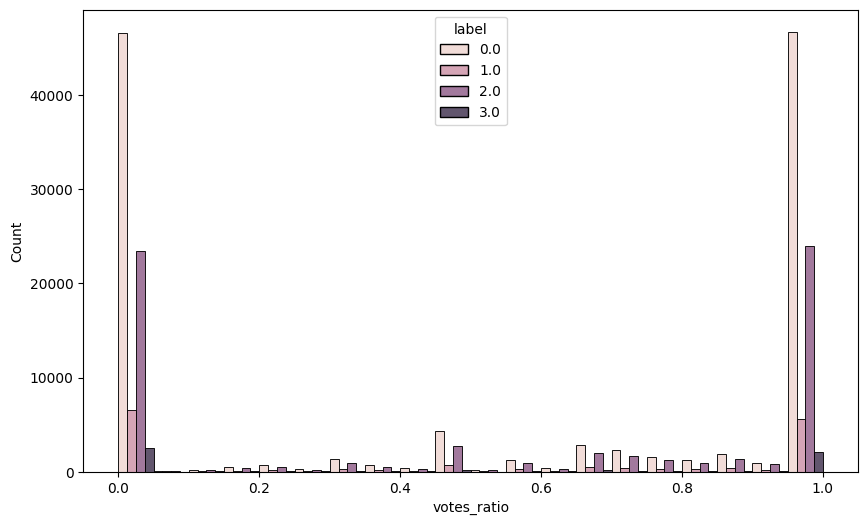
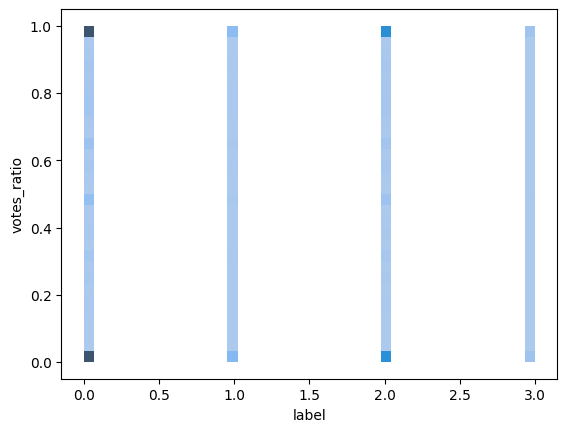
1. the plot is almost uniform 
2. since the vast majority snaps to either 0 or 1 it means there's very huge amount of posts with low engagement (1/0+1=1) 
2. Mini spikes neat 0.5
3. for label 1 and 3 the meadian line is perfectly 0.5 - half of data lean towards 0 or 1
4. for label 0 and 2 the median line is higer ~0.66 the data favors +ve ratios as more than half of data is above 0.5 
5. very few comments have ratios between 0.2-0.5 or 0.8 - This confirms High column votes are rare as 4/4+1 = 0.2 

In [45]:
# sns.boxplot(x='label', y='engagement_score', data=train_df)
# sns.scatterplot(x='label', y='engagement_score', data=train_df)

### Engagement Score vs Label
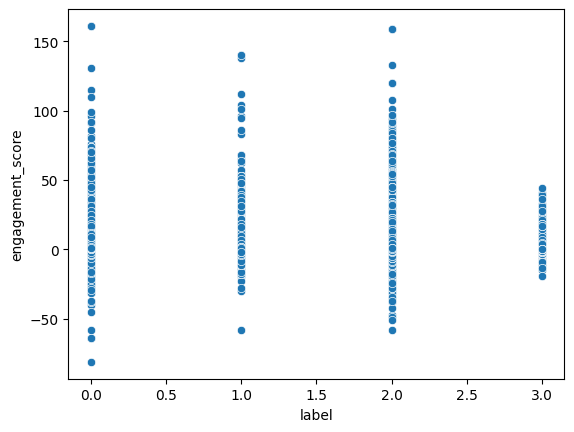
1. data is really skewed
2. vast majority of data is concentrated near zero
3. Have fat tails (heavy outliers)
4. although it's not very clear yet just from the looks it's seems like 
    - label 0 and 2 have the highest amount of +ve engagement
    - label 3.0 is much constrained, lack the wild virality and maxim at around 50

<Axes: xlabel='engagement_score', ylabel='comment_len'>

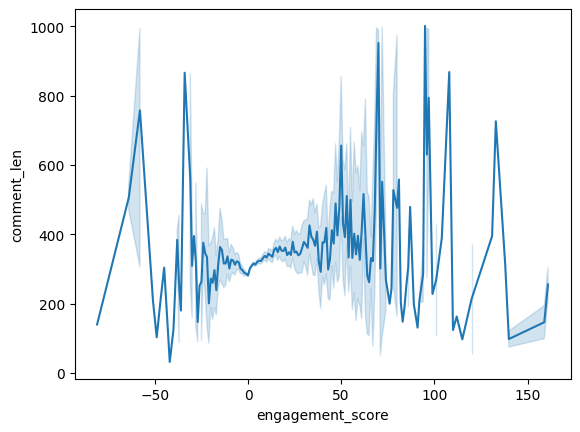

In [46]:
sns.lineplot(x='engagement_score', y='comment_len', data=train_df)

### Observations: engagement and comment length
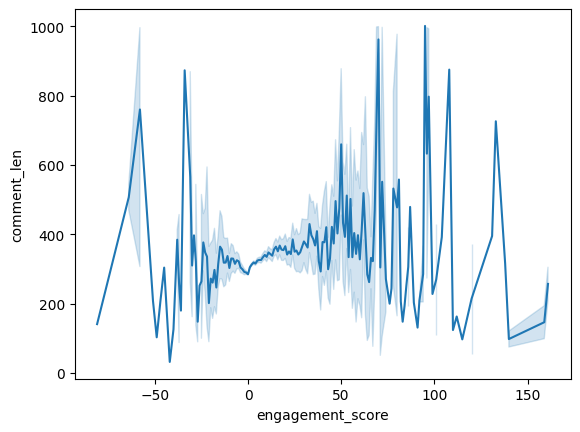
1. there's a stable zone between 0-50 with avg comment length ranging between 300-400
2. below -25 and above +75 thel line starts acting wildly and the shaded area which is the confidence interval(seaborn ~95%) gets very wide meaning there are few pointing at extreme scores, thus it doesn't feel like trend more like outliers
thus most of the users have an engagement score between 0 and 40, and they typically write comments that are 300–350 characters long. The data outside of that range is too thin to find any conclusions from

In [47]:
# sns.boxplot(x='label', y='num_!', data=train_df)
# sns.violinplot(x='label', y='num_!', data=train_df)

In [48]:
# sns.boxplot(x='label', y='num_ques', data=train_df)

### Emotion Obsevation: num_ques vs label and num_! vs label

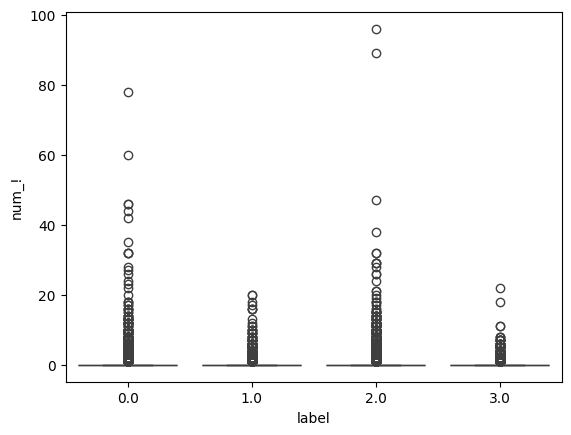
1. they are all sitting on zero, it means at least 75% of all comments in my dataset contain absolutely zero exclamation marks.

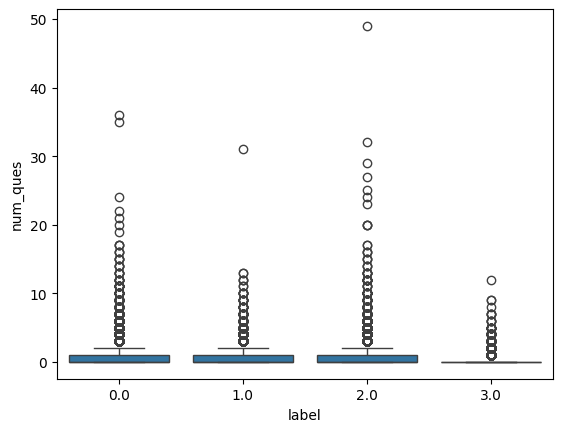

1. most no. of puncuations in lavel 0 and 2
    as we saw in the comment length plots, Labels 0.0 and 2.0 are where the extreme behavior exists.
- someone in Label 2.0 used almsot 100 exclamation marks in a single comment Label 0.0 isn't far behind, hitting around 80.
- outliers exist

conclusion:
- these classes contain highly expressive, possibly angry, confused, or spammy comments.

In [49]:
# sns.barplot(data = train_df, x = 'label', y = 'sentiment_vader', hue='label')
# sns.histplot(data=train_df, x='sentiment_vader', bins=30, kde=True, color='skyblue')

### Obeservation : Sentiment vs label
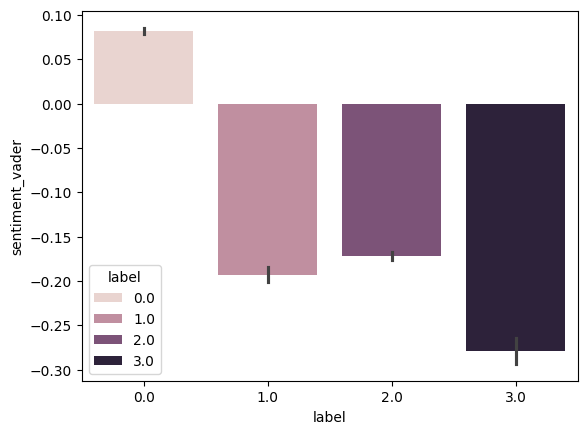
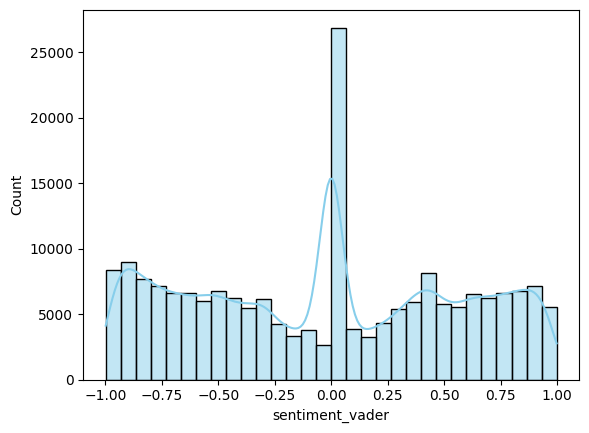
The higest number of comments have a neutral tone to it..
1. The bar for label 0.0 is the only one sitting above the zero line (averaging around +0.08). means comments in this category are generally positive, polite, or constructive
2. label 3 is the Highly Toxic or Angry Class as the bar plunges nearly -28, making it most negative category meaning these comments are likely highly aggressive, containing strong insults, swearing, or intense negative emotion.
3. labels 1.0 and 2.0 both sit around -0.17 to -0.19, 


In [50]:
# sns.countplot(x='created_hour', hue='label', data=train_df)

### Observations: hour vs label
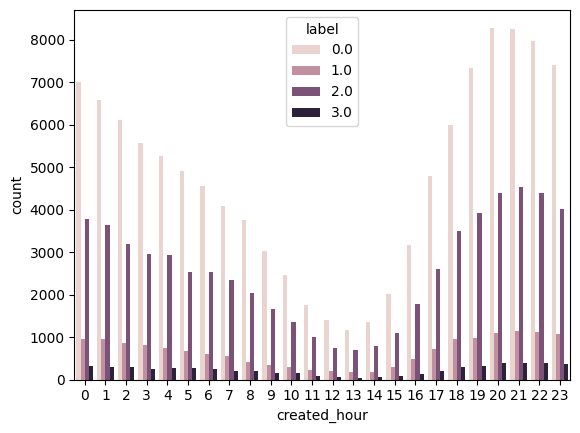
1. **Night Owl Supremacy!** 
2. best timer ranges between 7-9pm and stay high well past midnight
3. most probably users are scrolling and commenting primarily during evening and late night hours..
4. pretty much all the labels follow exact same curve.. means that more comments in the time frame are general - thus won't help much in prediction

In [51]:
# sns.countplot(x='weekday', hue='label', data=train_df) #0 represents Monday and 6 represents Sunday
# sns.countplot(x='weekend', hue='label', data=train_df) #0 represents Monday and 6 represents Sunday

### Weekday vs Label
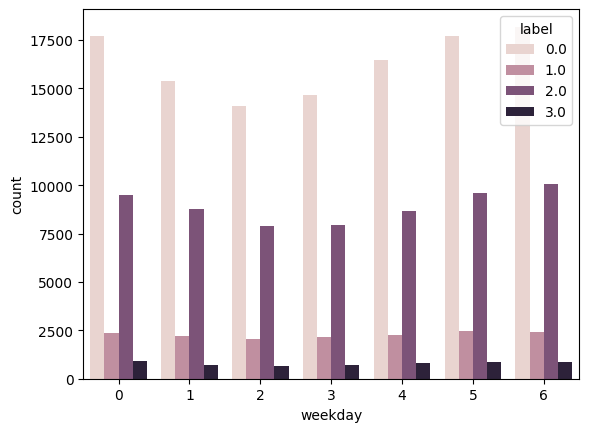
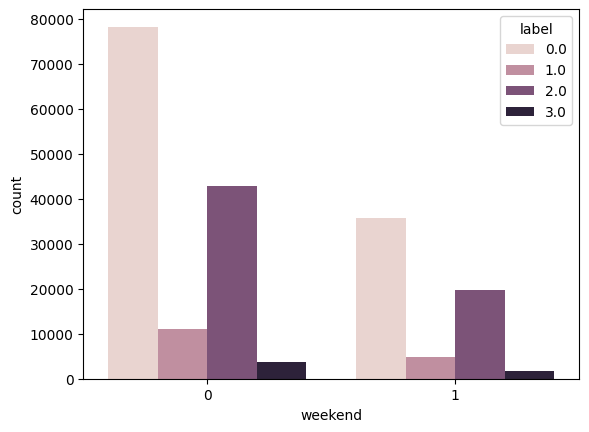

- highs- Days 0, 5, and 6 (Mon, Sat, Sun) have the highest activity.
- lows- Mid-week dips hard, with Day 2 (Wednesday) being the lowest.
- users are most active on weekends and right after (Monday), then drop off mid-week when things get busy.

There’s a noticeable jump from Sunday -> Monday, people seem to engage more right after weekends.

In [52]:
# pd.crosstab(train_df['gender'], train_df['label'], normalize='index').plot(kind='bar', stacked=True)

### Gender vs label
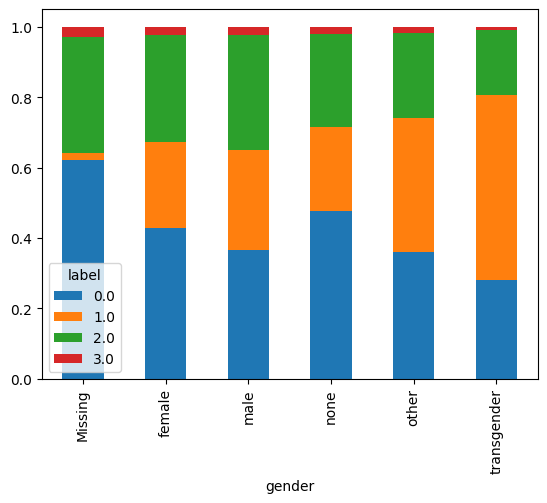

1. missing baseline;; missing is dominated by 0(blue) and 2
2. transgender is dominated by label 1 and least by label 3
3. orange spikes from nothing in missing to taking 25-50% in distribution
    - means: whatever label 1 is its' perhaps identity attack or controversial or specific type of engagement **It's heavily trigged the moment gender identity is involved or even mentioned**

since we have isolated the missing ones in actual final dataset it'd be of help in analysis

<Axes: >

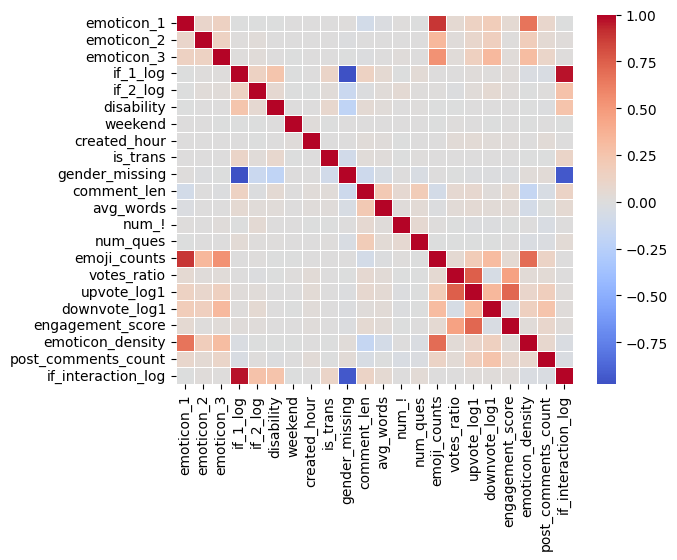

In [53]:
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_1_log','if_2_log','disability', 'weekend', 'created_hour','is_trans',
                'gender_missing', 'comment_len','avg_words',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log'] #excluded: ['post_id', 'comments'(in tf-idf), word_cnt,'race_missing', 'religion_missing', 'if_1', 'if_2', 'if_1_log']

corr = X_train[numerical_col].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)

### Heat Map Analysis 
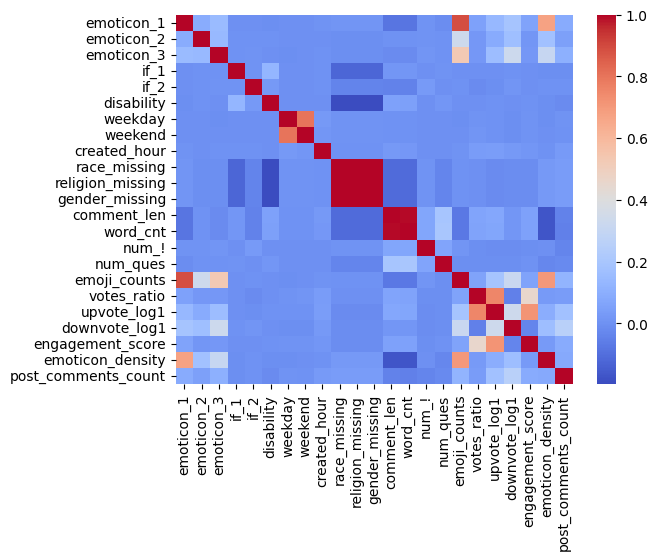
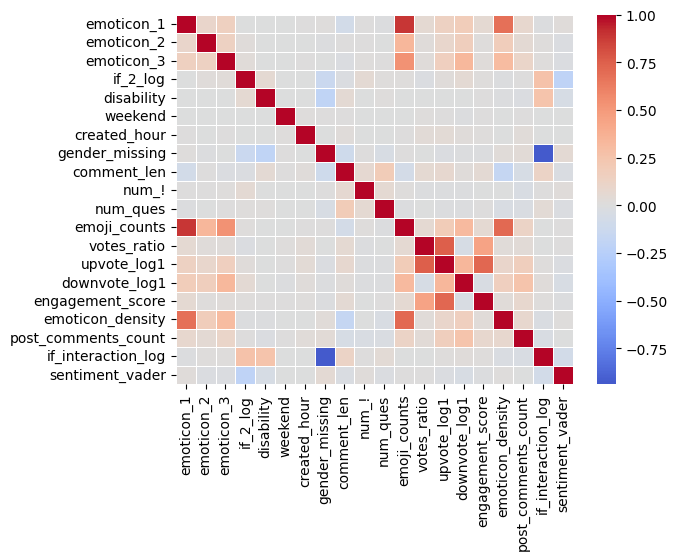
1. The missing data block in the middle, since they're perfectly correlated that means is a user didn't provide their race or any other two[gender, religion] means they didn't provide other 3 as well.. 
    - Keeping all three won't give any new informations, thus keep any 1 and drop other two
2. If you notice *comment_len* and *word_cnt* are almost almost itentical(same gradient) - can drop 1 or 2
    - Also if notice there's a red block in middle: more words -> higer charecter length
    - Drop: *word_cnt* is is better to keep helps with nlp as kinda like tokens
3. Engagement clusters near right bottom - upvote_log1, engagement_score, vote_ratio
    - that means that since engagement scores and ratios are mathematically calculated using the raw upvote/downvote counts, they are highly dependent on each other.
4. correlation between emoticon_1, emoji_counts, and emoticon_density
    - If someone uses a lot of emojis overall (emoji_counts), they naturally have a higher emoticon_density and are highly likely to have triggered whatever specific emoji emoticon_1 represents.
5. As we had guess above *weekend* and *weekday* interset - as we can drop either; drop weekday
6. Since these 'if_1', 'if_2', 'if_1_log', 'if_2_log' and 'if_interaction_log' were heavly correlated so to avoid feature bloating i've decided to keep only 'if_2_log' and 'if_interaction_log'
7. if we notice a blue cell bwt if_interaction_log and sentiment_vader is the only string negative correlation in the matrix rest everything is either red(positive) or white(no relationship). Lgbm already learn the high interaction and negative sentiment is label 3.0 but it'll take 2-3 levels to get so why not create a interation term the encodes the joint patter in single col.(if_interaction_sentiment). The model can now learn that in one split instead of two, which means it needs fewer trees and learns it more reliably.

In [54]:
# sns.scatterplot(data = train_df, x = "label", y="avg_words")

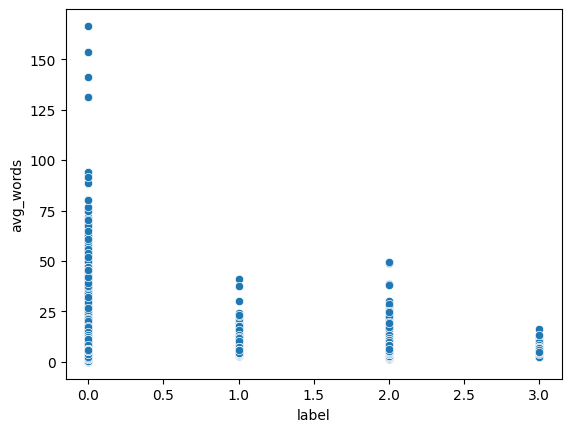

### Denoting correctly before ML training:

In [55]:
import copy
X_train_split = copy.deepcopy(X_train_final)
X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

In [56]:
unique, counts = np.unique(y_val_split, return_counts=True)
print("\nClass distribution in Validation set:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} rows")


Class distribution in Validation set:
Label 0: 22835 rows
Label 1: 3183 rows
Label 2: 12488 rows
Label 3: 1094 rows


# Model Training:

In [57]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train_split)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_split
)
CLASS_WEIGHTS = {
    int(c): float(w) for c, w in zip(classes, weights)
}
print("CLASS_WEIGHTS:", CLASS_WEIGHTS)

CLASS_WEIGHTS: {0: 0.4335544899165736, 1: 3.1095406360424027, 2: 0.7927610506085843, 3: 9.051428571428572}


## Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter= 1000, class_weight=CLASS_WEIGHTS, C=1.0, n_jobs=-1) #'balanced'

lr.fit(X_train_split, y_train_split)
y_pred = lr.predict(X_val_split)

lr_macro = f1_score(y_val_split, y_pred, average='macro')
lr_c3    = f1_score(y_val_split, y_pred, average=None)[3]

print(classification_report(y_val_split, y_pred))
print("f1_sctrore: ", f1_score(y_val_split, y_pred, average='macro'))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.68      0.85      0.76      3183
           2       0.88      0.86      0.87     12488
           3       0.50      0.78      0.61      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.86      0.80     39600
weighted avg       0.91      0.90      0.90     39600

f1_sctrore:  0.796702007320448


Result:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.68      0.85      0.76      3183
           2       0.88      0.86      0.87     12488
           3       0.50      0.78      0.61      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.85      0.80     39600
weighted avg       0.91      0.90      0.90     39600

f1_sctrore:  0.7970909375118818

In [59]:
# param_grid = {'C': [0.1, 1.0, 5.0]}
# lr_base = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=500)

# print("Starting Grid Search...")
# grid_search = GridSearchCV(
#     estimator=lr_base,
#     param_grid=param_grid,
#     scoring='f1_macro', 
#     cv=3,               
#     verbose=3
# )
# grid_search.fit(X_train_final, y_train_split)

In [60]:
# print("\n" + "="*40)
# print(f"Best Parameters Found: {grid_search.best_params_}")
# print("="*40)

# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_val_final)
# print(classification_report(y_val_split, y_pred))

## LightGBM

In [61]:
# using lighgm
import lightgbm as lgb
from sklearn.metrics import f1_score, classification_report
import joblib


X_tr = X_train_split.tocsr()
X_va = X_val_split.tocsr()

In [62]:
# # mode1 = joblib.load('/kaggle/input/datasets/kradarsh04/recent-model/lgbm_hpt_v1.pkl')

lgbm_model = joblib.load('/kaggle/input/datasets/kradarsh04/recent-model/lgbm_model_m3_nonltk.pkl')

In [63]:
# improvec score from 0.80->0.82
print("LightGBM: ")

# lgbm_model = lgb.LGBMClassifier(
#     n_estimators=500,
#     learning_rate=0.05,
#     num_leaves=127,
#     min_child_samples=35,
#     class_weight=CLASS_WEIGHTS,
#     subsample=0.8,
#     colsample_bytree=0.3,
#     reg_alpha=0.1,
#     n_jobs=-1,
#     random_state=42,
#     verbose=-1
# )

# print("done with model part")


# lgbm_model.fit(
#     X_tr, y_train_split,
#     eval_set=[(X_va, y_val_split)],
#     callbacks=[
#         lgb.early_stopping(65, verbose=True),
#         lgb.log_evaluation(100)
#     ]
# )

# lgbm_model.fit(X_tr, y_train_split)
# print("done with model.fit part")

# preds  = model.predict(X_va)
lgbm_preds = lgbm_model.predict(X_va)

scores = f1_score(y_val_split, lgbm_preds, average=None)
lgbm_macro = f1_score(y_val_split, lgbm_preds, average='macro')
lgbm_c3 = scores[3]

print(classification_report(y_val_split, lgbm_preds))
print(f"Macro F1  : {f1_score(y_val_split, lgbm_preds, average='macro'):.4f}")
print(f"Class 3 F1: {scores[3]:.4f}")

LightGBM: 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.84      0.79      3183
           2       0.88      0.91      0.89     12488
           3       0.70      0.64      0.67      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.83      0.83     39600
weighted avg       0.92      0.92      0.92     39600

Macro F1  : 0.8277
Class 3 F1: 0.6683


In [64]:
# joblib.dump(lgbm_model, 'lgbm_model_m3_nonltk.pkl')

In [65]:
# X_test_csr = X_test_final.tocsr()

# test_preds = model.predict(X_test_csr)
# sample['label'] = test_preds
# sample.to_csv('submission.csv', index=False)
# print("done")

In [66]:
import optuna
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, precision_recall_fscore_support
optuna.logging.set_verbosity(optuna.logging.WARNING)

## XGBoost


In [67]:
xgb_model = joblib.load('/kaggle/input/datasets/kradarsh04/recent-model/xgb_modelv1_nonltk.pkl')


In [68]:
print("MODEL 2: XGBoost")
weight_map = CLASS_WEIGHTS
sample_weights = np.array([weight_map[int(y)] for y in y_train_split])

# xgb_model = XGBClassifier(
#     n_estimators=700,
#     learning_rate=0.05,
#     max_depth=5,
#     colsample_bytree=0.3,
#     subsample=0.8,
#     reg_alpha=0.1,
#     reg_lambda=0.1,
#     objective='multi:softprob',
#     num_class=4,
#     eval_metric='mlogloss',
#     tree_method="hist", 
#     n_jobs=-1,
#     random_state=42,
#     early_stopping_rounds=65,
#     verbosity=0
# )

# xgb_model.fit(
#     X_tr, y_train_split,
#     sample_weight=sample_weights,
#     eval_set=[(X_va, y_val_split)],
#     verbose=100
# )

xgb_preds = xgb_model.predict(X_va)

xgb_macro = f1_score(y_val_split, xgb_preds, average='macro')
scores = f1_score(y_val_split, xgb_preds, average=None)
xgb_c3 = scores[3]

print(classification_report(y_val_split, xgb_preds))
print(f"Macro F1  : {xgb_macro:.4f}")
print(f"Class 3 F1: {xgb_c3:.4f}")

MODEL 2: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.69      0.87      0.77      3183
           2       0.90      0.85      0.87     12488
           3       0.50      0.78      0.61      1094

    accuracy                           0.91     39600
   macro avg       0.77      0.86      0.80     39600
weighted avg       0.92      0.91      0.91     39600

Macro F1  : 0.8041
Class 3 F1: 0.6107


In [69]:
# joblib.dump(xgb_model, 'xgb_modelv1_nonltk.pkl')

## HPT

In [70]:
# # HPT using Optuna
# print("HYPERPARAMETER TUNING; Optuna")

# def objective(trial):
#     params = {
#         "n_estimators": 1000,
#         "learning_rate": 0.05,
#         "num_leaves": trial.suggest_int("num_leaves", 31, 95, step=16),
#         "min_child_samples": trial.suggest_int("min_child_samples", 40, 120, step=20),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.5, step=0.05),
#         "subsample": trial.suggest_float("subsample", 0.7, 1.0, step=0.1),
#         "subsample_freq": 1,
#         "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 0.5, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 0.7, log=True),
    
#         "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.2),
#         "max_bin": trial.suggest_int("max_bin", 200, 300),
    
#         "class_weight": CLASS_WEIGHTS,
#         "n_jobs": -1,
#         "random_state": 42,
#         "verbose": -1,
#     }

#     m = lgb.LGBMClassifier(**params)
#     m.fit(
#         X_tr.values if hasattr(X_tr, 'columns') else X_tr, 
#         y_train_split,
#         eval_set=[(X_va.values if hasattr(X_va, 'columns') else X_va, y_val_split)],    callbacks=[
#             lgb.early_stopping(30, verbose=False),
#             lgb.log_evaluation(-1)
#         ]
#     )

#     preds    = m.predict(X_va)
#     macro    = f1_score(y_val_split, preds, average='macro')
#     c3       = f1_score(y_val_split, preds, average=None)[3]
#     combined = 0.6 * macro + 0.4 * c3

#     trial.set_user_attr("macro_f1",  macro)
#     trial.set_user_attr("class3_f1", c3)
#     trial.set_user_attr("best_iter", m.best_iteration_)

#     prec, rec, f1, _ = precision_recall_fscore_support(y_val_split, preds)
#     print(f"\n{'─'*60}")
#     print(f"  Trial {trial.number:>2}  |  combined: {combined:.4f}")
#     print(f"{'─'*60}")
#     print(f"  {'Class':<8} {'Precision':>10} {'Recall':>10} {'F1':>10}")
#     print(f"  {'─'*42}")
#     for cls in range(4):
#         tag = "  ← watch" if cls == 3 else ""
#         print(f"  {cls:<8} {prec[cls]:>10.4f} {rec[cls]:>10.4f} "
#               f"{f1[cls]:>10.4f}{tag}")
#     print(f"  {'─'*42}")
#     print(f"  macro {'':>13} {'':>10} {macro:>10.4f}")
#     print(f"  leaves={params['num_leaves']} | "
#           f"min_child={params['min_child_samples']} | "
#           f"col={params['colsample_bytree']:.2f} | "
#           f"α={params['reg_alpha']:.3f} | "
#           f"λ={params['reg_lambda']:.3f} | "
#           f"sub={params['subsample']:.1f} | "
#           f"iters={m.best_iteration_}")
#     print(f"{'─'*60}")
#     return combined


# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=5, timeout=18000)

# #summary
# print("  HPT RESULTS SUMMARY(sorted by combined score)")

# for t in sorted(study.trials, key=lambda x: x.value, reverse=True):
#     tag = "  ← BEST" if t.number == study.best_trial.number else ""
#     print(f"  {t.number:>6} {t.value:>10.4f} "
#           f"{t.user_attrs['macro_f1']:>10.4f} "
#           f"{t.user_attrs['class3_f1']:>10.4f} "
#           f"{t.user_attrs['best_iter']:>8} "
#           f"{t.params['num_leaves']:>8}{tag}")
# print(f"\n  Best params : {study.best_trial.params}")


##### HYPERPARAMETER TUNING; Optuna

```
────────────────────────────────────────────────────────────
  Trial  0  |  combined: 0.7700
────────────────────────────────────────────────────────────
  Class     Precision     Recall         F1
  ──────────────────────────────────────────
  0            0.9806     0.9475     0.9638
  1            0.7416     0.8505     0.7923
  2            0.8805     0.9008     0.8905
  3            0.6736     0.6828     0.6782  ← watch
  ──────────────────────────────────────────
  macro                              0.8312
  leaves=47 | min_child=100 | col=0.45 | α=0.060 | λ=0.107 | sub=0.8 | iters=673
────────────────────────────────────────────────────────────
```

```
────────────────────────────────────────────────────────────
  Trial  1  |  combined: 0.7666
────────────────────────────────────────────────────────────
  Class     Precision     Recall         F1
  ──────────────────────────────────────────
  0            0.9804     0.9486     0.9642
  1            0.7409     0.8461     0.7900
  2            0.8785     0.9009     0.8895
  3            0.6823     0.6636     0.6728  ← watch
  ──────────────────────────────────────────
  macro                              0.8291
  leaves=95 | min_child=40 | col=0.45 | α=0.092 | λ=0.198 | sub=0.9 | iters=374
────────────────────────────────────────────────────────────
```

```
────────────────────────────────────────────────────────────
  Trial  2  |  combined: 0.7660
────────────────────────────────────────────────────────────
  Class     Precision     Recall         F1
  ──────────────────────────────────────────
  0            0.9804     0.9481     0.9640
  1            0.7437     0.8461     0.7916
  2            0.8788     0.9028     0.8906
  3            0.6795     0.6627     0.6710  ← watch
  ──────────────────────────────────────────
  macro                              0.8293
  leaves=79 | min_child=60 | col=0.35 | α=0.014 | λ=0.685 | sub=1.0 | iters=453
────────────────────────────────────────────────────────────
```

```
────────────────────────────────────────────────────────────
  Trial  3  |  combined: 0.7685
────────────────────────────────────────────────────────────
  Class     Precision     Recall         F1
  ──────────────────────────────────────────
  0            0.9806     0.9476     0.9638
  1            0.7384     0.8505     0.7905
  2            0.8818     0.8998     0.8907
  3            0.6667     0.6856     0.6760  ← watch
  ──────────────────────────────────────────
  macro                              0.8302
  leaves=47 | min_child=80 | col=0.40 | α=0.156 | λ=0.296 | sub=0.7 | iters=684
────────────────────────────────────────────────────────────
```

```
  HPT RESULTS SUMMARY(sorted by combined score)
       0     0.7700     0.8312     0.6782      673       47  ← BEST
       3     0.7685     0.8302     0.6760      684       47
       1     0.7666     0.8291     0.6728      374       95
       2     0.7660     0.8293     0.6710      453       79

```
  Best params : {'num_leaves': 47, 'min_child_samples': 100, 'colsample_bytree': 0.45, 'subsample': 0.7999999999999999, 'reg_alpha': 0.05967388852428684, 'reg_lambda': 0.10718395739639798, 'min_split_gain': 0.022025987869221542, 'max_bin': 264}

In [71]:
# trained on best params
# final_lgbm = joblib.load('/kaggle/input/datasets/kradarsh04/recent-model/final_lgbm_03.pkl') #direct import to save time

final_lgbm = lgb.LGBMClassifier(
    n_estimators=2000,  # allow more, early stopping will cut
    learning_rate=0.05,
    num_leaves=79,
    min_child_samples=79,
    colsample_bytree=0.45,
    subsample=0.9,
    subsample_freq=1,
    reg_alpha=0.0772,
    reg_lambda=0.4798,
    min_split_gain=0.165,
    max_bin=272,
    class_weight=CLASS_WEIGHTS,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

final_lgbm.fit(
    X_tr, y_train_split,
    eval_set=[(X_va, y_val_split)],  # keep val ONLY for stopping
    callbacks=[
        lgb.early_stopping(30, verbose=True),
        lgb.log_evaluation(100)
    ]
)

final_lgbm_preds = final_lgbm.predict(X_va)
final_lgbm_scores = f1_score(y_val_split, final_lgbm_preds, average=None)

print("\n" + "="*57)
print("  FINAL LIGHTGBM RESULTS (after HPT)")
print("="*57)
print(classification_report(y_val_split, final_lgbm_preds))
print(f"  Macro F1  : {f1_score(y_val_split, final_lgbm_preds, average='macro'):.4f}")
print(f"  Class 3 F1: {final_lgbm_scores[3]:.4f}")
print("="*57)

Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 0.323679
[200]	valid_0's multi_logloss: 0.272968
[300]	valid_0's multi_logloss: 0.257916
[400]	valid_0's multi_logloss: 0.253357
Early stopping, best iteration is:
[423]	valid_0's multi_logloss: 0.25312


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  FINAL LIGHTGBM RESULTS (after HPT)
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.85      0.79      3183
           2       0.88      0.90      0.89     12488
           3       0.68      0.66      0.67      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.84      0.83     39600
weighted avg       0.92      0.92      0.92     39600

  Macro F1  : 0.8290
  Class 3 F1: 0.6710


In [72]:
joblib.dump(final_lgbm, '/kaggle/working/final_lgbm_03_nonltk.pkl')

['/kaggle/working/final_lgbm_03_nonltk.pkl']

## ENSEMBLE

In [73]:
# Find best blend weight on validation set
print("ENSEMBLE:")

proba_lgbm = final_lgbm.predict_proba(X_va)
proba_xgb  = xgb_model.predict_proba(X_va)

best_score = 0
best_w     = 0.7
best_alpha = 1.0

for w in np.linspace(0.5, 0.9, 8):
    base_blend = w * proba_lgbm + (1 - w) * proba_xgb

    for alpha in np.linspace(1.0, 1.25, 6):   # bias class 3
        temp = base_blend.copy()
        temp[:, 3] *= alpha

        preds = temp.argmax(axis=1)

        macro = f1_score(y_val_split, preds, average='macro')
        c3    = f1_score(y_val_split, preds, average=None)[3]
        combined = 0.6 * macro + 0.4 * c3

        marker = " ← best" if combined > best_score else ""

        print(f"lgbm={w:.2f} / xgb={1-w:.2f} | alpha={alpha:.2f} → "
              f"Macro={macro:.4f} | C3={c3:.4f}{marker}")

        if combined > best_score:
            best_score = combined
            best_w = w
            best_alpha = alpha
            best_macro_ens = macro
            best_c3_ens = c3

print(f"\nBest blend → lgbm={best_w:.2f} / xgb={1-best_w:.2f}")
print(f"Best alpha → {best_alpha:.2f}")
print(f"Ensemble Macro F1 : {best_macro_ens:.4f}")
print(f"Ensemble Class3 F1: {best_c3_ens:.4f}")

#
# best_macro_ens=0.8340
# best_c3_ens=0.6859

ENSEMBLE:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lgbm=0.50 / xgb=0.50 | alpha=1.00 → Macro=0.8253 | C3=0.6664 ← best
lgbm=0.50 / xgb=0.50 | alpha=1.05 → Macro=0.8252 | C3=0.6661
lgbm=0.50 / xgb=0.50 | alpha=1.10 → Macro=0.8249 | C3=0.6650
lgbm=0.50 / xgb=0.50 | alpha=1.15 → Macro=0.8249 | C3=0.6650
lgbm=0.50 / xgb=0.50 | alpha=1.20 → Macro=0.8248 | C3=0.6645
lgbm=0.50 / xgb=0.50 | alpha=1.25 → Macro=0.8236 | C3=0.6603
lgbm=0.56 / xgb=0.44 | alpha=1.00 → Macro=0.8268 | C3=0.6703 ← best
lgbm=0.56 / xgb=0.44 | alpha=1.05 → Macro=0.8264 | C3=0.6686
lgbm=0.56 / xgb=0.44 | alpha=1.10 → Macro=0.8260 | C3=0.6672
lgbm=0.56 / xgb=0.44 | alpha=1.15 → Macro=0.8256 | C3=0.6658
lgbm=0.56 / xgb=0.44 | alpha=1.20 → Macro=0.8265 | C3=0.6694
lgbm=0.56 / xgb=0.44 | alpha=1.25 → Macro=0.8255 | C3=0.6653
lgbm=0.61 / xgb=0.39 | alpha=1.00 → Macro=0.8276 | C3=0.6727 ← best
lgbm=0.61 / xgb=0.39 | alpha=1.05 → Macro=0.8275 | C3=0.6721
lgbm=0.61 / xgb=0.39 | alpha=1.10 → Macro=0.8268 | C3=0.6695
lgbm=0.61 / xgb=0.39 | alpha=1.15 → Macro=0.8262 | C3=0.6669
lgb

Code output:


```
## ENSEMBLE
lgbm=0.50 / xgb=0.50 | alpha=1.00 → Macro=0.8284 | C3=0.6739 ← best
lgbm=0.50 / xgb=0.50 | alpha=1.05 → Macro=0.8275 | C3=0.6708
lgbm=0.50 / xgb=0.50 | alpha=1.10 → Macro=0.8264 | C3=0.6669
lgbm=0.50 / xgb=0.50 | alpha=1.15 → Macro=0.8260 | C3=0.6659
lgbm=0.50 / xgb=0.50 | alpha=1.20 → Macro=0.8259 | C3=0.6656
lgbm=0.50 / xgb=0.50 | alpha=1.25 → Macro=0.8263 | C3=0.6672
lgbm=0.56 / xgb=0.44 | alpha=1.00 → Macro=0.8297 | C3=0.6757 ← best
lgbm=0.56 / xgb=0.44 | alpha=1.05 → Macro=0.8294 | C3=0.6745
lgbm=0.56 / xgb=0.44 | alpha=1.10 → Macro=0.8289 | C3=0.6725
lgbm=0.56 / xgb=0.44 | alpha=1.15 → Macro=0.8272 | C3=0.6669
lgbm=0.56 / xgb=0.44 | alpha=1.20 → Macro=0.8272 | C3=0.6667
lgbm=0.56 / xgb=0.44 | alpha=1.25 → Macro=0.8278 | C3=0.6694
lgbm=0.61 / xgb=0.39 | alpha=1.00 → Macro=0.8304 | C3=0.6781 ← best
lgbm=0.61 / xgb=0.39 | alpha=1.05 → Macro=0.8298 | C3=0.6754
lgbm=0.61 / xgb=0.39 | alpha=1.10 → Macro=0.8297 | C3=0.6751
lgbm=0.61 / xgb=0.39 | alpha=1.15 → Macro=0.8292 | C3=0.6733
lgbm=0.61 / xgb=0.39 | alpha=1.20 → Macro=0.8282 | C3=0.6700
lgbm=0.61 / xgb=0.39 | alpha=1.25 → Macro=0.8276 | C3=0.6678
lgbm=0.67 / xgb=0.33 | alpha=1.00 → Macro=0.8319 | C3=0.6817 ← best
lgbm=0.67 / xgb=0.33 | alpha=1.05 → Macro=0.8312 | C3=0.6787
lgbm=0.67 / xgb=0.33 | alpha=1.10 → Macro=0.8313 | C3=0.6794
lgbm=0.67 / xgb=0.33 | alpha=1.15 → Macro=0.8302 | C3=0.6748
lgbm=0.67 / xgb=0.33 | alpha=1.20 → Macro=0.8300 | C3=0.6742
lgbm=0.67 / xgb=0.33 | alpha=1.25 → Macro=0.8295 | C3=0.6725
lgbm=0.73 / xgb=0.27 | alpha=1.00 → Macro=0.8319 | C3=0.6804
lgbm=0.73 / xgb=0.27 | alpha=1.05 → Macro=0.8326 | C3=0.6826 ← best
lgbm=0.73 / xgb=0.27 | alpha=1.10 → Macro=0.8320 | C3=0.6804
lgbm=0.73 / xgb=0.27 | alpha=1.15 → Macro=0.8317 | C3=0.6795
lgbm=0.73 / xgb=0.27 | alpha=1.20 → Macro=0.8308 | C3=0.6760
lgbm=0.73 / xgb=0.27 | alpha=1.25 → Macro=0.8300 | C3=0.6734
lgbm=0.79 / xgb=0.21 | alpha=1.00 → Macro=0.8322 | C3=0.6811
lgbm=0.79 / xgb=0.21 | alpha=1.05 → Macro=0.8317 | C3=0.6793
lgbm=0.79 / xgb=0.21 | alpha=1.10 → Macro=0.8325 | C3=0.6818
lgbm=0.79 / xgb=0.21 | alpha=1.15 → Macro=0.8319 | C3=0.6796
lgbm=0.79 / xgb=0.21 | alpha=1.20 → Macro=0.8312 | C3=0.6772
lgbm=0.79 / xgb=0.21 | alpha=1.25 → Macro=0.8314 | C3=0.6783
lgbm=0.84 / xgb=0.16 | alpha=1.00 → Macro=0.8332 | C3=0.6833 ← best
lgbm=0.84 / xgb=0.16 | alpha=1.05 → Macro=0.8327 | C3=0.6817
lgbm=0.84 / xgb=0.16 | alpha=1.10 → Macro=0.8318 | C3=0.6784
lgbm=0.84 / xgb=0.16 | alpha=1.15 → Macro=0.8319 | C3=0.6783
lgbm=0.84 / xgb=0.16 | alpha=1.20 → Macro=0.8317 | C3=0.6776
lgbm=0.84 / xgb=0.16 | alpha=1.25 → Macro=0.8310 | C3=0.6755
lgbm=0.90 / xgb=0.10 | alpha=1.00 → Macro=0.8340 | C3=0.6859 ← best
lgbm=0.90 / xgb=0.10 | alpha=1.05 → Macro=0.8334 | C3=0.6840
lgbm=0.90 / xgb=0.10 | alpha=1.10 → Macro=0.8329 | C3=0.6823
lgbm=0.90 / xgb=0.10 | alpha=1.15 → Macro=0.8316 | C3=0.6775
lgbm=0.90 / xgb=0.10 | alpha=1.20 → Macro=0.8311 | C3=0.6760
lgbm=0.90 / xgb=0.10 | alpha=1.25 → Macro=0.8310 | C3=0.6753

Best blend → lgbm=0.90 / xgb=0.10
Best alpha → 1.00
Ensemble Macro F1 : 0.8340
Ensemble Class3 F1: 0.6859
```

In [74]:
#using best ensembling blend we found :

print("FINAL ENSEMBLE:")
best_w = 0.90   # lgbm weight
best_alpha = 1.00 #class3

# Predict
proba_lgbm = final_lgbm.predict_proba(X_va)
proba_xgb  = xgb_model.predict_proba(X_va)
blended = best_w * proba_lgbm + (1 - best_w) * proba_xgb
blended[:, 3] *= best_alpha
ensemble_preds = np.argmax(blended, axis=1)
ensemble_macro = f1_score(y_val_split, ensemble_preds, average='macro')
ensemble_c3 = f1_score(y_val_split, ensemble_preds, average=None)[3]

print(f"Best blend → lgbm={best_w:.2f} / xgb={1-best_w:.2f}")
print(f"Best alpha → {best_alpha:.2f}")
print(f"Ensemble Macro F1 : {ensemble_macro:.4f}")
print(f"Ensemble Class3 F1: {ensemble_c3:.4f}")

# summary
print("\n" + "="*60)
print("Final Summary")
print("="*60)
final_lgbm_macro = f1_score(y_val_split, final_lgbm_preds, average='macro')
print(f"  {'Model':<35} {'Macro F1':>10} {'Class3':>8}")
print(f"  {'─'*53}")
print(f"  {'Logistic Regression':<35} {lr_macro:>10.4f} {lr_c3:>8.4f}")
print(f"  {'XGBoost':<35} {xgb_macro:>10.4f} {xgb_c3:>8.4f}")
print(f"  {'LightGBM (HPT best params)':<35} {lgbm_macro:>10.4f} {lgbm_c3:>8.4f}")
print(f"  {'LightGBM (HPT retrained lr=0.05)':<35} {final_lgbm_macro:>10.4f} {final_lgbm_scores[3]:>8.4f}")
print(f"  {'Ensemble (LightGBM+XGBoost)':<35} {best_macro_ens:>10.4f} {best_c3_ens:>8.4f}")
print(f"  {'─'*53}")
print("="*60)
print(f"Best Model is LightGBM (HPT retrained lr=0.05): {final_lgbm_macro:>10.4f} ")

FINAL ENSEMBLE:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best blend → lgbm=0.90 / xgb=0.10
Best alpha → 1.00
Ensemble Macro F1 : 0.8286
Ensemble Class3 F1: 0.6703

Final Summary
  Model                                 Macro F1   Class3
  ─────────────────────────────────────────────────────
  Logistic Regression                     0.7967   0.6065
  XGBoost                                 0.8041   0.6107
  LightGBM (HPT best params)              0.8277   0.6683
  LightGBM (HPT retrained lr=0.05)        0.8290   0.6710
  Ensemble (LightGBM+XGBoost)             0.8303   0.6791
  ─────────────────────────────────────────────────────
Best Model is LightGBM (HPT retrained lr=0.05):     0.8290 


# Submission

In [75]:
X_test_csr = X_test_final.tocsr()
test_preds = final_lgbm.predict(X_test_csr)
sample['label'] = test_preds
sample.to_csv('/kaggle/working/submission.csv', index=False)

print("\nLabel distribution in submission:")
print(sample['label'].value_counts().sort_index())

# save models
# joblib.dump(final_lgbm, '/kaggle/working/lgbm_v23_final.pkl')
# joblib.dump(xgb_model,  '/kaggle/working/xgb_v23.pkl')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Label distribution in submission:
label
0    56791
1     9126
2    33267
3     2816
Name: count, dtype: int64


### **Miscellaneous**

In [76]:
# df.head()

# df_train.head()
# df_train.tail()

# df_test.shape
# sample.shape
# print(df_train.shape)

# print(df_test.columns)
# print(len(df_test.columns))

# df_train['label'].value_counts()
# df_train.head(10)

# # from sklearn.dummy import DummyClassifier
# # x_train = train.drop(columns = ["label"])
# # y_train = train['label']

# # dummy = DummyClassifier(strategy='most_frequent')
# # dummy.fit(x_train, y_train)

# # prediction = dummy.predict(test)
# # prediction

# #dummg submission
# # sample['label']= prediction
# # sample.to_csv("submission.csv", index = False)

# # sample

# # milestone-1 Ques
# df_train.shape

# objects = df_train.select_dtypes(include='object').columns
# len(objects)


# numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
# len(numerical_objs)

# null_vals = df_train.columns[df_train.isna().any()].tolist()
# null_vals

# num_classes = df_train['label'].nunique()
# print(num_classes)
# print(df_train['if_2'].min())

# #@title Milestone-2

# df_train.columns
# df_train.head()

# # created_date -> datetime
# pd.to_datetime(df_train["created_date"]).value_counts() #we got "may(05)"

# # df_train.iloc[:, 2:5]
# df_train["total_emoticons"] = df_train.iloc[:, 2:5].sum(axis = 1)

# df_train["total_emoticons"].max()

# # train.loc[(train["label"]==3), "comment"].len().median() #only works when using .str
# df_train.loc[(df_train["label"]==3), "comment"].str.len().median()

# # prev val of upvote ==10
# # train[train["upvote"]==10]

# # min-max normalisation -> x-min/max-min 
# min_ = df_train['upvote'].min()
# max_ = df_train['upvote'].max()
# # display(min_, max_)
# # df_train["upvote"] = (df_train["upvote"] - min_)/(max_-min_)
# # since we already want for upvote 10 we'll do it directly
# print((10- min_)/(max_-min_))

# df_train.loc[(df_train["label"]==1), "comment"].str.split().str.len().mean()

# len(df_train[df_train["comment"].str.contains("Trump", case = False, na = False)])

# df_train.head()

# words = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']


# sentence = df_train["comment"][0].split()
# print(sentence)
# m = len(sentence)
# for i in sentence:
#     if i in words: m-=1
#     else:print(i)
# print(m)

# tokens = df_train["comment"].str.lower().str.split().explode().nunique()
# tokens

# # from sklearn.feature_extraction.text import TfidfVectorizer
# # tfidr = TfidfVectorizer(stop_words = 'english', min_df = 5, ngram_range= (1,2))


# # tfidr_mat = tfidr.fit_transform(df_train['comment'].fillna(''))
# # print(len(tfidr_mat.get_feature_names_out()))

# # df_train.columns

# # Milestone 3

# x = df_train.drop(columns=['label']).copy()
# y = df_train['label'].astype(int).copy()
# # x,y
# x_train, x_vald, y_train, y_vald = train_test_split(
#     x,y,test_size = 0.20, stratify=y, random_state= 42
# )
# a, b = x_train.shape
# c,d = x_vald.shape
# a,b,c,d,a+c

# def extract_date(df):
#     df = df.copy()
#     df['created_date'] = pd.to_datetime(df['created_date'])
#     df["day"] = df['created_date'].dt.day.fillna(0).astype(int)
#     df["month"] = df['created_date'].dt.month.fillna(0).astype(int)
#     df["year"] = df['created_date'].dt.year.fillna(0).astype(int)
#     return df
# x_train = extract_date(x_train)
# x_vald = extract_date(x_vald)
# # x_train, x_vald
# display(x_train['month'].mode().iloc[0])

